# Universität Hildesheim - Mapping

In [1]:
from google.cloud import bigquery
import pandas as pd
from typing import Union
import re
import json
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [3]:
client = bigquery.Client(project='subugoe-collaborative')

In [20]:
oal = client.query(f"""
                    SELECT 
                        'not assigned' AS fak_name,
                        'Universität Hildesheim' AS parent_name,
                        raw_affiliation_string,
                        openalex_id
                    FROM (
                      SELECT oal.id AS openalex_id, inst.address_full AS raw_affiliation_string
                      FROM `subugoe-collaborative.resources.kb_a_addr_inst_202601` AS inst
                      JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202601` AS kb_inst
                          ON inst.inst_id_top = kb_inst.inst_id
                      JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                          ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                      WHERE oal.type IN ('article', 'review') 
                          AND kb_inst.ror = 'https://ror.org/02f9det96' -- 'Universität Hildesheim'
                          AND is_paratext=FALSE 
                          AND is_retracted=FALSE 
                          AND is_xpac=FALSE
                          AND publication_year BETWEEN 2020 AND 2025
                    )
                    """).to_dataframe()

In [21]:
oal.head()

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,not assigned,Universität Hildesheim,"Institut für Psychologie, Universität ...",https://openalex.org/W4295268056
1,not assigned,Universität Hildesheim,Department of Information Science and Natural ...,https://openalex.org/W4285030115
2,not assigned,Universität Hildesheim,"Faculty for Mathematics, Natural Sciences, Eco...",https://openalex.org/W4307046931
3,not assigned,Universität Hildesheim,University Outpatient Clinic for Children and ...,https://openalex.org/W4291016589
4,not assigned,Universität Hildesheim,Institute for Information Science and Speech T...,https://openalex.org/W4303470830


In [374]:
MAPPING_DICT = {
    'Center for World Music (CWM)': ['center for world music'],
    'Centrum für Lehrerbildung und Bildungsforschung (CeLeB)': ['lehrerbildung'],
    'Fachbereich I: Erziehungs- und Sozialwissenschaften': ['education(al)? science', 'psycholog(ie|y)', 'sport', 'erziehungswissenschaft',
                                                            'so(z|c)ial', 'grundschuldidaktik', 'theologie', 'geschichte', '(institute|faculty) of education',
                                                            'psychopathology', 'migration', 'research methods'
                                                           ],
    'Fachbereich II: Kulturwissenschaften und Ästhetische Kommunikation': ['english', 'philosoph(ie|y)', 'kulturpolitik', 'musikwissenschaft',
                                                                           'cultural policy'
                                                                          ],
    'Fachbereich III: Sprach- und Informationswissenschaften': ['language (science|processing)', 'linguistics', 'deutsche sprache', 'informationswissenschaften',
                                                                'sprachtechnologie', '(?<!economics\sand\s)information science', 'inter(k|c)ultur(elle|al)',
                                                                'übersetzungswissenschaft', 'german language',
                                                               ],
    'Fachbereich IV: Mathematik, Naturwissenschaften, Wirtschaft und Informatik': ['institut für informatik', 'ecology', 'machine learning',
                                                                                   'biolog(ie|y)', 'angewandte informatik', 'business administration',
                                                                                   'mat(h)?emati(k|cs)', 'geograph(ie|y)', 'information systems',
                                                                                   'computer science', 'software systems engineering', 'wirtschaftsinformatik',
                                                                                   'data analytics', 'ismll,', 'economics education'
                                                                                  ],
    #'Universitätsbibliothek': [],
    #'Zentrum für Geschlechterforschung': []
}

In [375]:
with open('./mapping_tables_fak/hildesheim.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT, f, ensure_ascii=False)

In [376]:
def map_address(address: str) -> Union[str, None]:
    for k, v in MAPPING_DICT.items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [377]:
df_with_inst = oal.copy()

df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned', 'fak_name'] = \
           df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned']['raw_affiliation_string'].apply(map_address)

In [378]:
df_with_inst

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,Fachbereich I: Erziehungs- und Sozialwissensch...,Universität Hildesheim,"Institut für Psychologie, Universität ...",https://openalex.org/W4295268056
1,Fachbereich III: Sprach- und Informationswisse...,Universität Hildesheim,Department of Information Science and Natural ...,https://openalex.org/W4285030115
2,"Fachbereich IV: Mathematik, Naturwissenschafte...",Universität Hildesheim,"Faculty for Mathematics, Natural Sciences, Eco...",https://openalex.org/W4307046931
3,Fachbereich I: Erziehungs- und Sozialwissensch...,Universität Hildesheim,University Outpatient Clinic for Children and ...,https://openalex.org/W4291016589
4,Fachbereich III: Sprach- und Informationswisse...,Universität Hildesheim,Institute for Information Science and Speech T...,https://openalex.org/W4303470830
...,...,...,...,...
1395,"Fachbereich IV: Mathematik, Naturwissenschafte...",Universität Hildesheim,Department of Biology University of Hildesheim...,https://openalex.org/W4387779670
1396,"Fachbereich IV: Mathematik, Naturwissenschafte...",Universität Hildesheim,"Department of Biology, University of Hildeshei...",https://openalex.org/W4387779670
1397,None,Universität Hildesheim,Universität Hildesheim,https://openalex.org/W4388916625
1398,None,Universität Hildesheim,"University of Hildesheim, GERMANY",https://openalex.org/W4367293390


In [379]:
df_with_inst[df_with_inst.fak_name.isnull()].raw_affiliation_string.unique()

array(['University of Hildesheim, Germany',
       'Robert Bosch GmbH, University of Hildesheim, Hildesheim, Germany',
       'University of Hildesheim,Robert Bosch GmbH,Hildesheim,Germany',
       'University of Hildesheim, Hildesheim, Germany',
       'University of Hildesheim,Hildesheim,Germany',
       'University of Heidelberg University of Hildesheim University of Leipzig University of Saarland Professional College of',
       'University of Hildesheim', 'Stiftung Universität Hildesheim',
       'Universität Hildesheim, Hildesheim',
       'Corresponding author.; University of Hildesheim, Universitätsplatz 1, 31141 Hildesheim, Germany',
       'University of Hildesheim, Universitätsplatz 1, 31141 Hildesheim, Germany',
       'University of Hildesheim , Hildesheim , Germany',
       'Universität Hildesheim',
       'Stiftung Universität Hildesheim (UB Hildesheim)',
       '26557 Universität Hildesheim , Hildesheim , Germany',
       'Hildesheim University, Hildesheim, Germany',
  

In [380]:
df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()

,fak_name,openalex_id
0,Center for World Music (CWM),1
1,Centrum für Lehrerbildung und Bildungsforschun...,4
2,Fachbereich I: Erziehungs- und Sozialwissensch...,484
3,Fachbereich II: Kulturwissenschaften und Ästhe...,30
4,Fachbereich III: Sprach- und Informationswisse...,80
5,"Fachbereich IV: Mathematik, Naturwissenschafte...",330
6,NaN,471


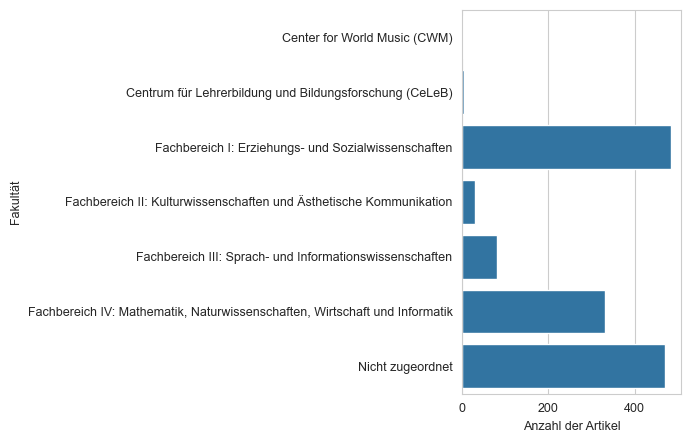

In [381]:
df_plot = df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()
df_plot.fillna('Nicht zugeordnet', inplace=True)

fig, ax = plt.subplots(figsize=(7, 4.5))

sns.barplot(data=df_plot, 
            x='openalex_id', 
            y='fak_name',
            ax=ax)

ax.set(xlabel='Anzahl der Artikel', ylabel='Fakultät')

plt.tight_layout()

plt.show()

In [382]:
df_plot[df_plot.fak_name != 'Nicht zugeordnet'].openalex_id.sum() / df_plot.openalex_id.sum()

0.6635714285714286

In [544]:
MAPPING_DICT_DEPT = {
    'Fachbereich I: Erziehungs- und Sozialwissenschaften': {
        'Institut für Erziehungswissenschaft': ['erziehungswissenschaft', 'applied educational science', 'general education', '(department|institute) (for|of) educational science'],
        'Institut für Evangelische Theologie': ['evangelische theologie'],
        'Institut für Geschichte': ['institut für geschichte'],
        'Institut für Grundschuldidaktik und Sachunterricht': ['grundschuldidaktik'],
        'Institut für Katholische Theologie': ['katholische theologie'],
        'Institut für Psychologie': ['psycholog(ie|y)', 'psychopathology'],
        'Institut für Sozial- und Organisationspädagogik': ['organisationspädagogik', 'organi(s|z)ation(al)? (studies|education)', 'organi(s|z)ational pedagogy'],
        'Institut für Sozialwissenschaften': ['(department|institute) (of|for) social sciences', 'institut für sozialwissenschaften', 'migration policy'],
        'Institut für Sportwissenschaft': ['biosciences of sports', 'sport(s)? science', 'sportwissen(-)?schaft'],
    },
    'Fachbereich II: Kulturwissenschaften und Ästhetische Kommunikation': {
        'Institut für Bildende Kunst und Kunstwissenschaft': ['kunstwissenschaft'],
        'Institut für Kulturpolitik': ['cultural policy', 'kulturpolitik'],
        'Institut für Literarisches Schreiben und Literaturwissenschaft': ['(department|institute) of english', 'english department'],
        'Institut für Medien, Theater und Populäre Kultur': ['populäre kultur'],
        'Institut für Musik und Musikwissenschaft': ['musikwissenschaft'],
        'Institut für Philosophie': ['philosoph(ie|y)'],
    },
    'Fachbereich III: Sprach- und Informationswissenschaften': {
        'Institut für deutsche Sprache und Literatur': ['deutsche sprache', 'german language'],
        'Institut für englische Sprache und Literatur': ['englische sprache'],
        'Institut für Informationswissenschaft und Sprachtechnologie': ['language processing', 'sprachtechnologie', '(language|speech) (technology|science)'],
        'Institut für Interkulturelle Kommunikation': ['interkulturelle', 'intercultural'],
        'Institut für Übersetzungswissenschaft und Fachkommunikation': ['übersetzungswissenschaft'],
    },
    'Fachbereich IV: Mathematik, Naturwissenschaften, Wirtschaft und Informatik': {
        'Institut für Betriebswirtschaft und Wirtschaftsinformatik': ['ismll,', 'betriebswirtschaft', 'wirtschaftsinformatik', 'economics education', 'data analytics',
                                                                      'business administration'
                                                                     ],
        'Institut für Biologie und Chemie': ['biolog(ie|y)', 'zoology', 'plant ecology', 'chemie'],
        'Institut für Geographie': ['geograph(ie|y)', 'geoecology'],
        'Institut für Informatik': ['(information|software) systems', 'institut für informatik', 'computer science'],
        'Institut für Mathematik, Mathematikdidaktik und Informatikdidaktik': ['insti(t)?ute (of|for) mathematics', 'institut f(ü|u)?r (angewandte\s)?mathematik'],
        'Institut für Physik': ['institut für physik'],
        'Institut für Technik': ['institut für technik'],
    }
}

In [545]:
with open('./mapping_tables_dept/hildesheim.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT_DEPT, f, ensure_ascii=False)

In [546]:
def map_dept(address: str, faculty: str) -> Union[str, None]:
    if faculty in MAPPING_DICT_DEPT:
        for k, v in MAPPING_DICT_DEPT.get(faculty).items():
            pattern = re.compile(r'|'.join(v), re.IGNORECASE)
            res = bool(pattern.search(address))
            if res:
                return k
        return None
    else:
        return None

In [547]:
df_with_inst.loc[df_with_inst['fak_name'] == 'Fachbereich IV: Mathematik, Naturwissenschaften, Wirtschaft und Informatik', 'dept_name'] = \
    df_with_inst.loc[df_with_inst['fak_name'] == 'Fachbereich IV: Mathematik, Naturwissenschaften, Wirtschaft und Informatik']['raw_affiliation_string'].apply(map_dept, 
                                                                                                    faculty='Fachbereich IV: Mathematik, Naturwissenschaften, Wirtschaft und Informatik')

In [548]:
df_with_inst[(df_with_inst['fak_name'] == 'Fachbereich IV: Mathematik, Naturwissenschaften, Wirtschaft und Informatik') & df_with_inst['dept_name'].isnull()].raw_affiliation_string.unique()[:20]

array(['Leibniz-Institut für die Pädagogik der Naturwissenschaften und Mathematik, Kiel and Universität Hildesheim',
       'Research Group Ecology and Environmental Education, University of Hildesheim, Universitaetsplatz 1, 31141, Hildesheim, Germany'],
      dtype=object)

In [549]:
df_with_inst[df_with_inst['fak_name'] == 'Fachbereich IV: Mathematik, Naturwissenschaften, Wirtschaft und Informatik'].groupby(['dept_name'], dropna=False)['openalex_id'].count().reset_index()

,dept_name,openalex_id
0,Institut für Betriebswirtschaft und Wirtschaft...,34
1,Institut für Biologie und Chemie,129
2,Institut für Geographie,49
3,Institut für Informatik,82
4,"Institut für Mathematik, Mathematikdidaktik un...",34
5,NaN,2


In [550]:
df_with_inst[df_with_inst['fak_name'] == 'Fachbereich IV: Mathematik, Naturwissenschaften, Wirtschaft und Informatik']

,fak_name,parent_name,raw_affiliation_string,openalex_id,dept_name
2,"Fachbereich IV: Mathematik, Naturwissenschafte...",Universität Hildesheim,"Faculty for Mathematics, Natural Sciences, Eco...",https://openalex.org/W4307046931,Institut für Informatik
10,"Fachbereich IV: Mathematik, Naturwissenschafte...",Universität Hildesheim,"University of Hildesheim, Department of Geogra...",https://openalex.org/W4292133223,Institut für Geographie
26,"Fachbereich IV: Mathematik, Naturwissenschafte...",Universität Hildesheim,"Department of Biology, Universität Hildesheim,...",https://openalex.org/W4224291562,Institut für Biologie und Chemie
32,"Fachbereich IV: Mathematik, Naturwissenschafte...",Universität Hildesheim,"Department of Biology, University of Hildeshei...",https://openalex.org/W4308155999,Institut für Biologie und Chemie
34,"Fachbereich IV: Mathematik, Naturwissenschafte...",Universität Hildesheim,"University of Hildesheim,Information Systems a...",https://openalex.org/W4318148243,Institut für Informatik
...,...,...,...,...,...
1380,"Fachbereich IV: Mathematik, Naturwissenschafte...",Universität Hildesheim,Institute of Geography University of Hildeshei...,https://openalex.org/W4416536079,Institut für Geographie
1390,"Fachbereich IV: Mathematik, Naturwissenschafte...",Universität Hildesheim,Institute for Economics and Information System...,https://openalex.org/W3210313117,Institut für Informatik
1394,"Fachbereich IV: Mathematik, Naturwissenschafte...",Universität Hildesheim,"Department of Biology, University of Hildeshei...",https://openalex.org/W4316507344,Institut für Biologie und Chemie
1395,"Fachbereich IV: Mathematik, Naturwissenschafte...",Universität Hildesheim,Department of Biology University of Hildesheim...,https://openalex.org/W4387779670,Institut für Biologie und Chemie
